In [1]:
# Import required libraries for handling class imbalance and model evaluation.
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from imblearn.over_sampling import SMOTE

In [2]:
# Load the engineered dataset that will be used for model training with SMOTE.
df = pd.read_csv("../data/processed/engineered_data.csv")

preprocessor = joblib.load("../artifacts/preprocessor.pkl")

In [3]:
# Display the dataset shape and column information to verify that it loaded correctly.
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (10000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     10000 non-null  str    
 1   System                   10000 non-null  int64  
 2   Control                  10000 non-null  str    
 3   Type                     10000 non-null  str    
 4   Air temperature (K)      10000 non-null  float64
 5   Process temperature (K)  10000 non-null  float64
 6   Rotational speed (rpm)   10000 non-null  float64
 7   Torque (Nm)              10000 non-null  float64
 8   Tool wear (min)          10000 non-null  float64
 9   Diagnostic               10000 non-null  str    
 10  Year                     10000 non-null  int64  
 11  Month                    10000 non-null  int64  
 12  Day                      10000 non-null  int64  
 13  Day_of_Week              10000 non-null  int64  
 14  Quarter

In [4]:
# Separate the features and target variable.

X = df.drop(columns=["Date", "Diagnostic"])

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Diagnostic"])

In [5]:
# Split the dataset into training and testing sets while preserving the original class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
# Apply the saved preprocessing pipeline to transform the training and testing feature sets.
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [7]:
# Apply SMOTE only to the preprocessed training data to balance the minority classes.
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:", X_train_processed.shape)
print("After SMOTE :", X_train_smote.shape)

Before SMOTE: (8000, 138)
After SMOTE : (46332, 138)


In [8]:
# Display the class distribution after applying SMOTE to confirm that the training data is balanced.


smote_distribution = pd.Series(y_train_smote).value_counts().sort_index()

print(smote_distribution)

0    7722
1    7722
2    7722
3    7722
4    7722
5    7722
Name: count, dtype: int64


In [9]:
# Train the baseline Random Forest model using the SMOTE-balanced training data.
rf_smote = RandomForestClassifier(
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
# Make predictions on the original test set using the trained SMOTE model.
y_pred_smote = rf_smote.predict(X_test_processed)

In [11]:
# Calculate the overall accuracy of the Random Forest model trained with SMOTE.
accuracy = accuracy_score(
    y_test,
    y_pred_smote
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9915


In [14]:
# Generate a detailed classification report to evaluate the performance of each class.
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        21
              No failure       0.99      1.00      1.00      1930
      Overstrain Failure       0.86      0.95      0.90        20
           Power Failure       1.00      1.00      1.00        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.33      0.12      0.18         8

                accuracy                           0.99      2000
               macro avg       0.70      0.68      0.68      2000
            weighted avg       0.99      0.99      0.99      2000



c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carol\Projects\Predictive-Maintenance-Intelligence-Platform\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

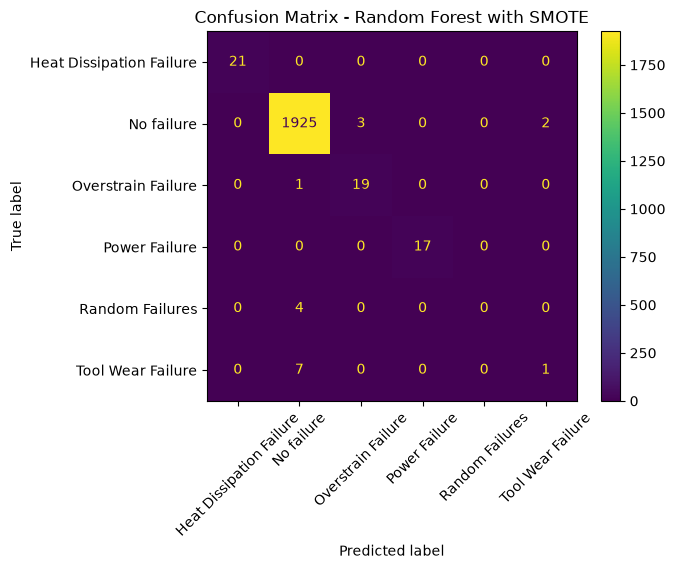

In [13]:
# Display the confusion matrix to visualize the model's classification performance.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Random Forest with SMOTE")

plt.show()

## Conclusion

SMOTE was applied to address the class imbalance in the training dataset and improve the model's ability to detect minority failure classes.

The Random Forest model trained with SMOTE achieved an overall accuracy of **99.15%** and maintained excellent performance for the majority class as well as Heat Dissipation Failure, Power Failure, and Overstrain Failure.

However, the model still struggled to identify **Random Failures** and **Tool Wear Failure**, indicating that SMOTE alone was not sufficient to overcome the extreme imbalance and limited number of original samples for these classes.

Based on the evaluation results, SMOTE did not provide a significant improvement over the baseline model for all minority classes. Therefore, the baseline Random Forest model remains the preferred model for this project.

# Future Improvements

Although SMOTE was applied to address class imbalance, the improvement for extremely rare failure classes such as Random Failures and Tool Wear Failure was limited.

Possible future improvements include:

- Experimenting with different SMOTE parameters such as `k_neighbors`.
- Evaluating advanced oversampling techniques like BorderlineSMOTE, ADASYN, or SMOTETomek.
- Exploring cost-sensitive learning using class weights.
- Collecting more real-world samples for rare failure classes, as the dataset contains very few examples of these failures.
- Comparing additional ensemble algorithms such as XGBoost or LightGBM.